<a href="https://colab.research.google.com/github/maamebirago/Cryptocurrency-prediction-using-python/blob/main/Cryptocurrency_Predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Load the datasets
eth_data = pd.read_csv('/content/ethereum dataset.csv')
btc_data = pd.read_csv('/content/bitcoin dataset.csv')

In [2]:
# Convert Date column to datetime format
eth_data["date"] = pd.to_datetime(eth_data["date"])
btc_data["Date"] = pd.to_datetime(btc_data["Date"])

In [3]:
# View first 5 rows of both datasets
display(btc_data.head(5))
display(eth_data.head(5))

,Date,Open,High,Low,Close,Volume,Currency
0,2019-06-18,9128.269531,9149.763672,8988.606445,9062.045898,952850.0,USD
1,2019-06-19,9068.174805,9277.677734,9051.094727,9271.459961,131077.0,USD
2,2019-06-20,9271.567383,9573.689453,9209.416992,9519.200195,83052.0,USD
3,2019-06-21,9526.833984,10130.935547,9526.833984,10127.998047,76227.0,USD
4,2019-06-22,10151.890625,11171.013672,10083.189453,10719.981445,84485.0,USD


,date,Open,High,Low,Close,price,Currency
0,2016-03-10,11.20,11.85,11.07,11.75,4,USD
1,2016-03-11,11.75,11.95,11.75,11.95,179,USD
2,2016-03-12,11.95,13.45,11.95,12.92,833,USD
3,2016-03-13,12.92,15.07,12.92,15.07,1295,USD
4,2016-03-14,15.07,15.07,11.40,12.50,92183,USD


In [4]:
# Check for missing values in Bitcoin data
bitcoin_missing = btc_data.isnull().sum()

# Check for missing values in Ethereum data
ether_missing = eth_data.isnull().sum()

In [5]:
# Print missing values for Bitcoin
print("Missing values in Bitcoin data:\n", bitcoin_missing)

# Print missing values in Ethereum
print("\nMissing values in Ethereum data:\n", ether_missing)

Missing values in Bitcoin data:
 Date        0
Open        0
High        0
Low         0
Close       0
Volume      0
Currency    0
dtype: int64

Missing values in Ethereum data:
 date        0
Open        0
High        0
Low         0
Close       0
price       0
Currency    0
dtype: int64


In [6]:
# Define the Target Variable (Future Closing Price)
eth_data["Target"] = eth_data["Close"].shift(-1)
btc_data["Target"] = btc_data["Close"].shift(-1)

In [7]:
# View the last row of the datasets
print("Last row of Ethereum data:")
display(eth_data.iloc[[-1]])

print("\nLast row of Bitcoin data:")
display(btc_data.iloc[[-1]])

Last row of Ethereum data:


,date,Open,High,Low,Close,price,Currency,Target
2357,2022-08-23,1626.7,1636.32,1615.55,1623.24,1053674,USD,NaN



Last row of Bitcoin data:


,Date,Open,High,Low,Close,Volume,Currency,Target
1150,2022-08-23,21337.318359,21412.892578,21280.458984,21303.986328,6955056.0,USD,NaN


In [8]:
# View first 8 rows of both datasets
print("First 8 rows of Bitcoin data:")
display(btc_data.head(8))

print("\nFirst 8 rows of Ethereum data:")
display(eth_data.head(8))

First 8 rows of Bitcoin data:


,Date,Open,High,Low,Close,Volume,Currency,Target
0,2019-06-18,9128.269531,9149.763672,8988.606445,9062.045898,952850.0,USD,9271.459961
1,2019-06-19,9068.174805,9277.677734,9051.094727,9271.459961,131077.0,USD,9519.200195
2,2019-06-20,9271.567383,9573.689453,9209.416992,9519.200195,83052.0,USD,10127.998047
3,2019-06-21,9526.833984,10130.935547,9526.833984,10127.998047,76227.0,USD,10719.981445
4,2019-06-22,10151.890625,11171.013672,10083.189453,10719.981445,84485.0,USD,11246.518555
5,2019-06-23,10718.117188,11293.773438,10561.124023,11246.518555,52072.0,USD,11010.517578
6,2019-06-24,11246.518555,11251.156250,10659.144531,11010.517578,106205.0,USD,11666.965820
7,2019-06-25,10999.733398,11676.888672,10999.733398,11666.965820,95820.0,USD,12827.663086



First 8 rows of Ethereum data:


,date,Open,High,Low,Close,price,Currency,Target
0,2016-03-10,11.20,11.85,11.07,11.75,4,USD,11.95
1,2016-03-11,11.75,11.95,11.75,11.95,179,USD,12.92
2,2016-03-12,11.95,13.45,11.95,12.92,833,USD,15.07
3,2016-03-13,12.92,15.07,12.92,15.07,1295,USD,12.50
4,2016-03-14,15.07,15.07,11.40,12.50,92183,USD,13.06
5,2016-03-15,12.63,13.42,11.98,13.06,39725,USD,12.88
6,2016-03-16,13.06,13.89,12.62,12.88,19240,USD,10.74
7,2016-03-17,12.58,12.61,10.44,10.74,89450,USD,10.74


In [9]:
# Drop NaN values caused by rolling calculations (from 'Target')
eth_data.dropna(inplace=True)
btc_data.dropna(inplace=True)

for df in [eth_data, btc_data]:
    df["Price_Spread"] = df["High"] - df["Low"]  # Daily price range
    df["Price_Change"] = df["Close"].pct_change()  # Percentage change in closing price


# Drop NaN values caused by rolling calculations (from 'Price_Change')
eth_data.dropna(inplace=True)
btc_data.dropna(inplace=True)

In [10]:
# Filter Method- Using Chi Test
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import KBinsDiscretizer

# Define feature sets separately
btc_features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Price_Change', 'Price_Spread']
eth_features = ['Open', 'High', 'Low', 'Close', 'Price_Change', 'Price_Spread']
target = 'Target'

# Convert numerical features into categorical bins
discretizer_btc = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
discretizer_eth = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
discretizer_target = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')  # For Target variable

btc_data_discretized = btc_data.copy()[btc_features + [target]]
eth_data_discretized = eth_data.copy()[eth_features + [target]]

btc_data_discretized[btc_features] = discretizer_btc.fit_transform(btc_data_discretized[btc_features])
eth_data_discretized[eth_features] = discretizer_eth.fit_transform(eth_data_discretized[eth_features])

# Discretize Target (Important Fix)
btc_data_discretized[target] = discretizer_target.fit_transform(btc_data_discretized[[target]])
eth_data_discretized[target] = discretizer_target.fit_transform(eth_data_discretized[[target]])

# Apply Chi-Square Test
selector_btc = SelectKBest(score_func=chi2, k='all')
selector_eth = SelectKBest(score_func=chi2, k='all')

btc_selected = selector_btc.fit(btc_data_discretized[btc_features], btc_data_discretized[target])
eth_selected = selector_eth.fit(eth_data_discretized[eth_features], eth_data_discretized[target])

# Display feature scores
btc_scores = pd.DataFrame({'Feature': btc_features, 'Chi2 Score': btc_selected.scores_})
eth_scores = pd.DataFrame({'Feature': eth_features, 'Chi2 Score': eth_selected.scores_})

print("\nBitcoin Feature Importance using Chi-Square Test:\n", btc_scores.sort_values(by='Chi2 Score', ascending=False))
print("\nEthereum Feature Importance using Chi-Square Test:\n", eth_scores.sort_values(by='Chi2 Score', ascending= False))


Bitcoin Feature Importance using Chi-Square Test:
         Feature   Chi2 Score
3         Close  1660.357047
0          Open  1641.664019
2           Low  1607.834758
1          High  1246.028004
4        Volume   105.667149
6  Price_Spread     6.539460
5  Price_Change     0.302909

Ethereum Feature Importance using Chi-Square Test:
         Feature   Chi2 Score
1          High  4855.073239
3         Close  4816.459208
0          Open  4776.593698
2           Low  4705.626377
5  Price_Spread   392.192092
4  Price_Change     0.309119


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Define features and target
btc_features = ['Open', 'High', 'Low', 'Close']
eth_features = ['Open', 'High', 'Low', 'Close']
target = 'Target'


# Split data into training and testing sets (80% train, 20% test)
X_btc_train, X_btc_test, y_btc_train, y_btc_test = train_test_split(btc_data[btc_features], btc_data[target], test_size=0.2, random_state=42)
X_eth_train, X_eth_test, y_eth_train, y_eth_test = train_test_split(eth_data[eth_features], eth_data[target], test_size=0.2, random_state=42)

# Standardize the features
scaler_btc = StandardScaler()
scaler_eth = StandardScaler()
X_btc_train_scaled = scaler_btc.fit_transform(X_btc_train)
X_btc_test_scaled = scaler_btc.transform(X_btc_test)
X_eth_train_scaled = scaler_eth.fit_transform(X_eth_train)
X_eth_test_scaled = scaler_eth.transform(X_eth_test)


In [12]:
# Initialize and train the Random Forest Regressor for Bitcoin
rf_btc = RandomForestRegressor(n_estimators=100, random_state=42)
rf_btc.fit(X_btc_train_scaled, y_btc_train)

# Make predictions on the Bitcoin test set
y_btc_pred = rf_btc.predict(X_btc_test_scaled)

# Evaluate Bitcoin model
mse_btc = mean_squared_error(y_btc_test, y_btc_pred)
r2_btc = r2_score(y_btc_test, y_btc_pred)

print("Bitcoin Random Forest Regressor Performance:")
print(f"Mean Squared Error: {mse_btc:.4f}")
print(f"R-squared: {r2_btc:.4f}")

Bitcoin Random Forest Regressor Performance:
Mean Squared Error: 2366806.7722
R-squared: 0.9924


In [13]:
# Initialize and train the Random Forest Regressor for Ethereum
rf_eth = RandomForestRegressor(n_estimators=100, random_state=42)
rf_eth.fit(X_eth_train_scaled, y_eth_train)

# Make predictions on the Ethereum test set
y_eth_pred = rf_eth.predict(X_eth_test_scaled)

# Evaluate Ethereum model
mse_eth = mean_squared_error(y_eth_test, y_eth_pred)
r2_eth = r2_score(y_eth_test, y_eth_pred)

print("\nEthereum Random Forest Regressor Performance:")
print(f"Mean Squared Error: {mse_eth:.4f}")
print(f"R-squared: {r2_eth:.4f}")


Ethereum Random Forest Regressor Performance:
Mean Squared Error: 8436.3157
R-squared: 0.9937


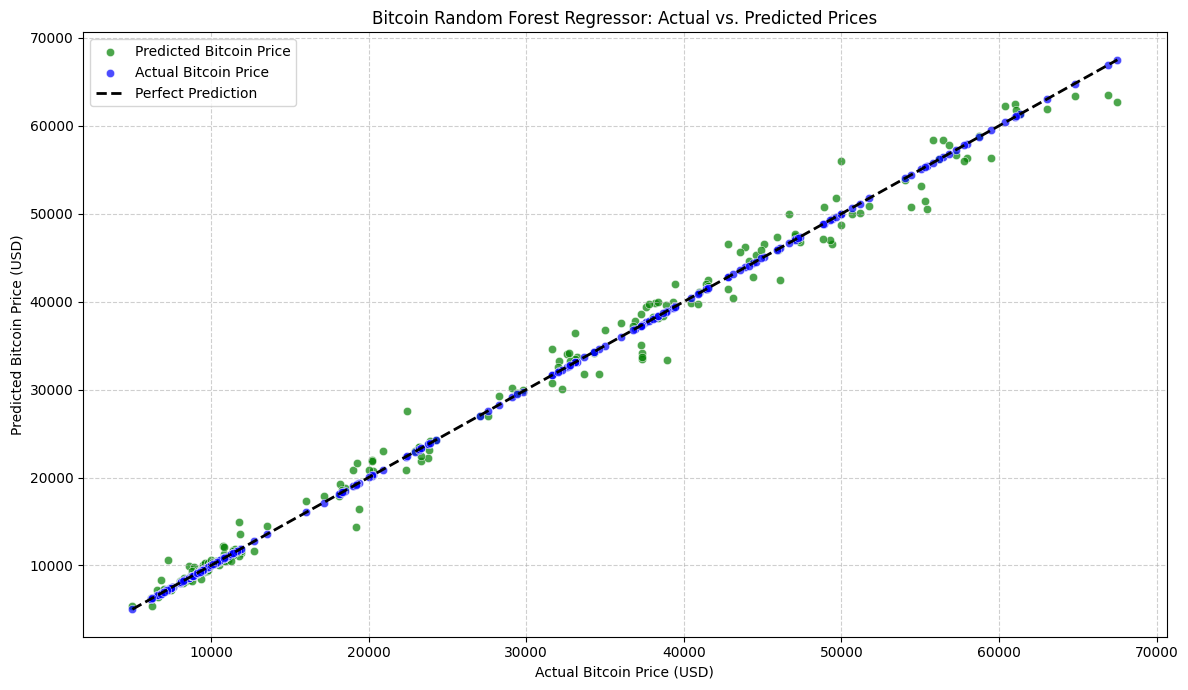

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Bitcoin Random Forest Regressor Results
plt.figure(figsize=(12, 7))
sns.scatterplot(x=y_btc_test, y=y_btc_pred, color='green', label='Predicted Bitcoin Price', alpha=0.7)
sns.scatterplot(x=y_btc_test, y=y_btc_test, color='blue', label='Actual Bitcoin Price', alpha=0.7)
plt.plot([y_btc_test.min(), y_btc_test.max()], [y_btc_test.min(), y_btc_test.max()], 'k--', lw=2, label='Perfect Prediction')

plt.title('Bitcoin Random Forest Regressor: Actual vs. Predicted Prices')
plt.xlabel('Actual Bitcoin Price (USD)')
plt.ylabel('Predicted Bitcoin Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

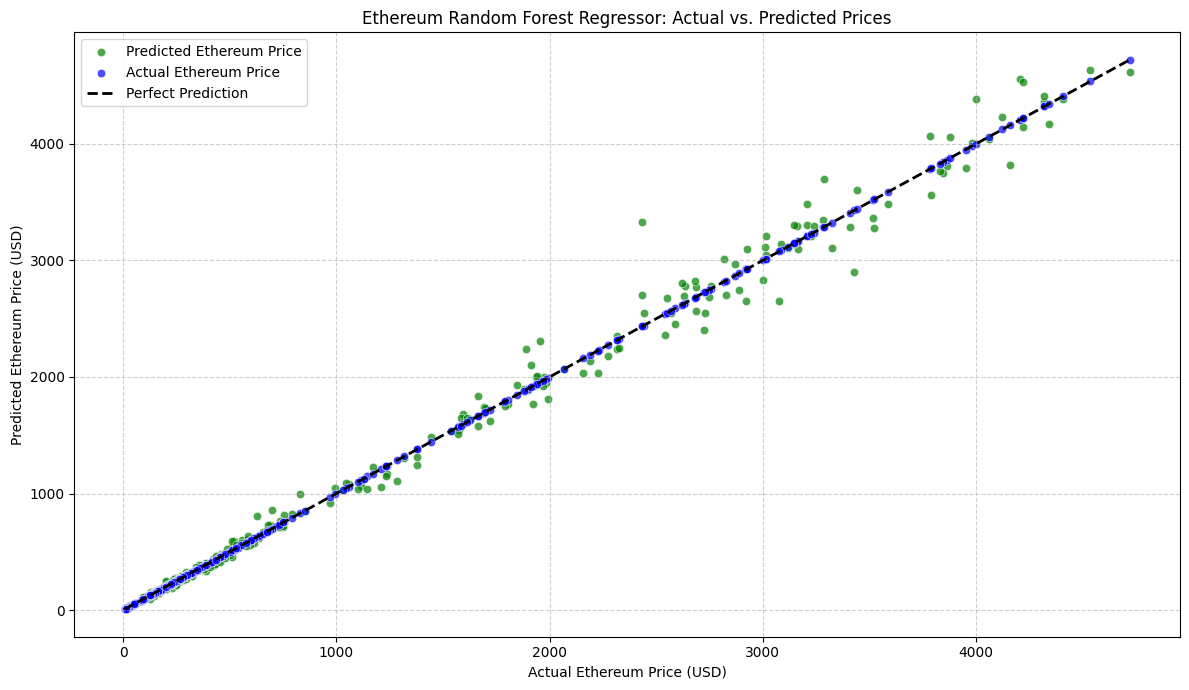

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Ethereum Random Forest Regressor Results
plt.figure(figsize=(12, 7))
sns.scatterplot(x=y_eth_test, y=y_eth_pred, color='green', label='Predicted Ethereum Price', alpha=0.7)
sns.scatterplot(x=y_eth_test, y=y_eth_test, color='blue', label='Actual Ethereum Price', alpha=0.7)
plt.plot([y_eth_test.min(), y_eth_test.max()], [y_eth_test.min(), y_eth_test.max()], 'k--', lw=2, label='Perfect Prediction')

plt.title('Ethereum Random Forest Regressor: Actual vs. Predicted Prices')
plt.xlabel('Actual Ethereum Price (USD)')
plt.ylabel('Predicted Ethereum Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Bitcoin Random Forest - RMSE: 1538.4430, R^2: 0.9924
Ethereum Random Forest - RMSE: 91.8494, R^2: 0.9937
Bitcoin Linear Regression - RMSE: 1358.6093, R^2: 0.9941
Ethereum Linear Regression - RMSE: 84.4462, R^2: 0.9947
Bitcoin KNN - RMSE: 1552.8651, R^2: 0.9923
Ethereum KNN - RMSE: 93.7400, R^2: 0.9935


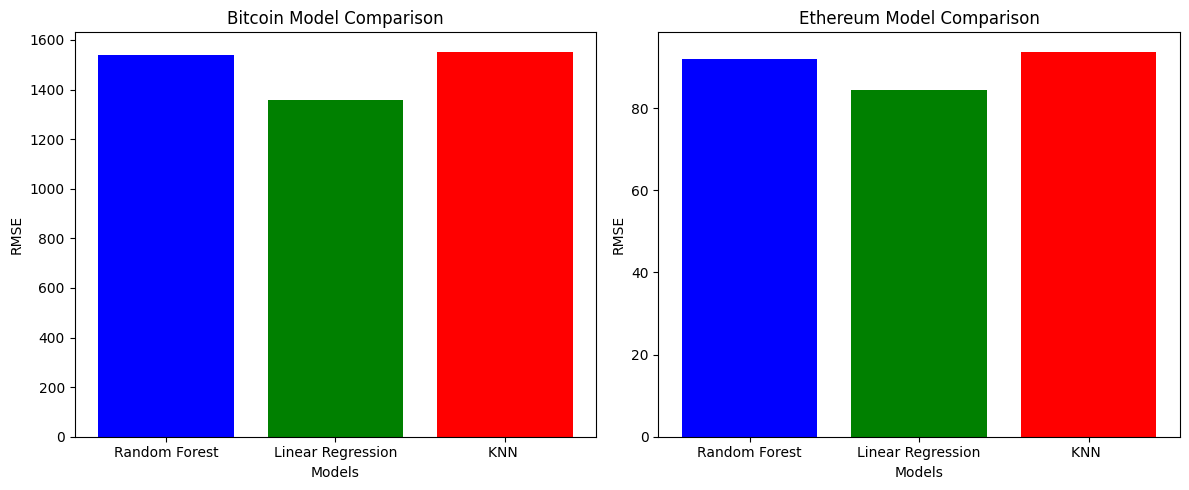

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt


# Define features and target
btc_features = ['Open', 'High', 'Low', 'Close']
eth_features = ['Open', 'High', 'Low', 'Close']
target = 'Target'

# Split data into training and testing sets (80% train, 20% test)
X_btc_train, X_btc_test, y_btc_train, y_btc_test = train_test_split(btc_data[btc_features], btc_data[target], test_size=0.2, random_state=42)
X_eth_train, X_eth_test, y_eth_train, y_eth_test = train_test_split(eth_data[eth_features], eth_data[target], test_size=0.2, random_state=42)

# Standardize the features
scaler_btc = StandardScaler()
scaler_eth = StandardScaler()
X_btc_train_scaled = scaler_btc.fit_transform(X_btc_train)
X_btc_test_scaled = scaler_btc.transform(X_btc_test)
X_eth_train_scaled = scaler_eth.fit_transform(X_eth_train)
X_eth_test_scaled = scaler_eth.transform(X_eth_test)

# Train Random Forest Regressor
rf_btc = RandomForestRegressor(n_estimators=100, random_state=42)
rf_eth = RandomForestRegressor(n_estimators=100, random_state=42)
rf_btc.fit(X_btc_train_scaled, y_btc_train)
rf_eth.fit(X_eth_train_scaled, y_eth_train)

# Train Linear Regression
lr_btc = LinearRegression()
lr_eth = LinearRegression()
lr_btc.fit(X_btc_train_scaled, y_btc_train)
lr_eth.fit(X_eth_train_scaled, y_eth_train)

# Train KNN
knn_btc = KNeighborsRegressor(n_neighbors=5)
knn_eth = KNeighborsRegressor(n_neighbors=5)
knn_btc.fit(X_btc_train_scaled, y_btc_train)
knn_eth.fit(X_eth_train_scaled, y_eth_train)

# Predictions
y_btc_pred_rf = rf_btc.predict(X_btc_test_scaled)
y_eth_pred_rf = rf_eth.predict(X_eth_test_scaled)
y_btc_pred_lr = lr_btc.predict(X_btc_test_scaled)
y_eth_pred_lr = lr_eth.predict(X_eth_test_scaled)
y_btc_pred_knn = knn_btc.predict(X_btc_test_scaled)
y_eth_pred_knn = knn_eth.predict(X_eth_test_scaled)

# Evaluate the models
btc_rmse_rf = np.sqrt(mean_squared_error(y_btc_test, y_btc_pred_rf))
eth_rmse_rf = np.sqrt(mean_squared_error(y_eth_test, y_eth_pred_rf))
btc_r2_rf = r2_score(y_btc_test, y_btc_pred_rf)
eth_r2_rf = r2_score(y_eth_test, y_eth_pred_rf)

btc_rmse_lr = np.sqrt(mean_squared_error(y_btc_test, y_btc_pred_lr))
eth_rmse_lr = np.sqrt(mean_squared_error(y_eth_test, y_eth_pred_lr))
btc_r2_lr = r2_score(y_btc_test, y_btc_pred_lr)
eth_r2_lr = r2_score(y_eth_test, y_eth_pred_lr)

btc_rmse_knn = np.sqrt(mean_squared_error(y_btc_test, y_btc_pred_knn))
eth_rmse_knn = np.sqrt(mean_squared_error(y_eth_test, y_eth_pred_knn))
btc_r2_knn = r2_score(y_btc_test, y_btc_pred_knn)
eth_r2_knn = r2_score(y_eth_test, y_eth_pred_knn)

# Print evaluation results
print(f'Bitcoin Random Forest - RMSE: {btc_rmse_rf:.4f}, R^2: {btc_r2_rf:.4f}')
print(f'Ethereum Random Forest - RMSE: {eth_rmse_rf:.4f}, R^2: {eth_r2_rf:.4f}')
print(f'Bitcoin Linear Regression - RMSE: {btc_rmse_lr:.4f}, R^2: {btc_r2_lr:.4f}')
print(f'Ethereum Linear Regression - RMSE: {eth_rmse_lr:.4f}, R^2: {eth_r2_lr:.4f}')
print(f'Bitcoin KNN - RMSE: {btc_rmse_knn:.4f}, R^2: {btc_r2_knn:.4f}')
print(f'Ethereum KNN - RMSE: {eth_rmse_knn:.4f}, R^2: {eth_r2_knn:.4f}')

# Visualization of the models

models = ['Random Forest', 'Linear Regression', 'KNN ']
rmse_values_btc = [btc_rmse_rf, btc_rmse_lr, btc_rmse_knn]
rmse_values_eth = [eth_rmse_rf, eth_rmse_lr, eth_rmse_knn]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(models, rmse_values_btc, color=['blue', 'green', 'red'])
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Bitcoin Model Comparison")

plt.subplot(1, 2, 2)
plt.bar(models, rmse_values_eth, color=['blue', 'green', 'red'])
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Ethereum Model Comparison")

plt.tight_layout()
plt.show()

In [17]:
# DataFrame for Bitcoin predictions
btc_predictions = pd.DataFrame({
    'Actual': y_btc_test,
    'Random Forest': y_btc_pred_rf,
    'Linear Regression': y_btc_pred_lr,
    'KNN Regression': y_btc_pred_knn
})

# DataFrame for Ethereum predictions
eth_predictions = pd.DataFrame({
    'Actual': y_eth_test,
    'Random Forest': y_eth_pred_rf,
    'Linear Regression': y_eth_pred_lr,
    'KNN Regression': y_eth_pred_knn
})

# Display first 10 rows
print("Bitcoin Predictions:\n", btc_predictions.head(10))
print("\nEthereum Predictions:\n", eth_predictions.head(10))

Bitcoin Predictions:
            Actual  Random Forest  Linear Regression  KNN Regression
175   7253.395020    7314.683008        7418.794646     7249.729688
753  34272.781250   34221.573164       33656.754252    33945.817187
468  10956.469727   10567.370166       10777.214661    10745.399414
241   9855.512695   10279.736465       10445.129847    10257.387305
668  60394.523438   62204.718086       61393.213256    61411.077344
219   8442.665039    8222.763276        8507.308147     8355.463867
868  63023.035156   61921.590430       62762.417900    62785.011719
421  11908.466797   11469.641582       11684.231629    11193.921875
352   9643.172852   10139.708506       10015.334017     9708.757227
329   9054.068359    8999.737100        8885.716265     8947.175391

Ethereum Predictions:
        Actual  Random Forest  Linear Regression  KNN Regression
673   1380.00      1245.2588        1265.442997        1227.064
1186   246.86       236.4604         232.703520         240.768
1653   385.25 